In [74]:
import datetime
from dataclasses import dataclass
from datetime import timedelta
import pathlib
import joblib
import pandera.polars as pa
import pandera.typing.polars
from pandera.typing.polars import DataFrame
from pandera.typing.polars import Series
import polars as pl
from typing import Annotated
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
#from notebooks.overnight_range_breakout_model import test_start
from typing import Generator

In [75]:
class Bar(pa.DataFrameModel):
    timestamp: pandera.typing.polars.Series[pl.Datetime("ns", "UTC")]
    open: pandera.typing.polars.Series[float]
    high: pandera.typing.polars.Series[float]
    low: pandera.typing.polars.Series[float]
    close: pandera.typing.polars.Series[float]
CCYS = ['jpy','chf','cad','aud','nzd','eur','gbp']
INVERSE_CCYS = ['chf','jpy','cad']
#NON_MAJORS = ['hkd','mxn','nok','sgd','sek','try','zar']
NON_MAJORS = ['nok','sek','mxn']

In [109]:
RAW_OHLC_COLUMNS = [
    f"{ccy}_{field}"
    for ccy in CCYS
    for field in ("open", "high", "low", "close")
]
class DayBar(pa.DataFrameModel):
    timestamp: pandera.typing.polars.Series[pl.Datetime("ns", "UTC")]
    open: pandera.typing.polars.Series[float]
    high: pandera.typing.polars.Series[float]
    low: pandera.typing.polars.Series[float]
    close: pandera.typing.polars.Series[float]

#OANDA
def get_oanda_hourly_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\Data\Oanda\\',f"oanda_{pair}_hourly.parquet")


def read_oanda_hourly_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_parquet(get_oanda_hourly_file_path(ccy))
    #
    df = df.with_columns(
        pl.col("timestamp")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)

def hourly_to_daily(df: DataFrame[DayBar]) -> DataFrame[DayBar]:
    daily = (
        df.sort("timestamp")  # group_by_dynamic requires sorted input
        .group_by_dynamic("timestamp", every="1d", closed="left", label="left")
        .agg(
            pl.col("open").first(),
            pl.col("high").max(),
            pl.col("low").min(),
            pl.col("close").last(),
        )
    )

    saturdays = (
        daily.filter(pl.col("timestamp").dt.weekday() == 5)  # Monday=1 ... Friday=5
        .select(
            pl.col("timestamp").dt.offset_by("1d"),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.col("close"),
        )
        .join(daily.select("timestamp"), on="timestamp", how="anti")  # don't duplicate real Saturday bars
    )

    combined = pl.concat([daily, saturdays]).sort("timestamp")
    return DayBar.validate(combined)

def read_oanda_data(ccy: str) -> DataFrame[DayBar]:
    df = hourly_to_daily(read_oanda_hourly_data(ccy))

    return DayBar.validate(df)

def get_dukas_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\\',f"{pair}_d1_sep_2026.csv")



def read_dukas_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_csv(get_dukas_file_path(ccy))

    df = df.with_columns(
        pl.from_epoch("timestamp", time_unit="ms")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)



In [122]:
INITIAL_CUT = datetime.datetime(2016, 1, 1, tzinfo=datetime.timezone.utc)
LATER_CUT = datetime.datetime(2026, 9, 1, tzinfo=datetime.timezone.utc)
ccy = "jpy"
dukas= read_dukas_data(ccy).filter((pl.col('timestamp') > INITIAL_CUT) & (pl.col('timestamp') < LATER_CUT))
oanda= read_oanda_data(ccy).filter((pl.col('timestamp') > INITIAL_CUT) & (pl.col('timestamp') < LATER_CUT))

In [123]:
((dukas['close']-dukas['close'].shift(1))/dukas['close'].shift(1)).describe()

statistic,value
str,f64
"""count""",3888.0
"""null_count""",1.0
"""mean""",-0.000061
"""std""",0.00481
"""min""",-0.029972
"""25%""",-0.002057
"""50%""",0.0
"""75%""",0.001662
"""max""",0.038548


In [124]:
((oanda['close']-oanda['close'].shift(1))/oanda['close'].shift(1)).describe()

statistic,value
str,f64
"""count""",3881.0
"""null_count""",1.0
"""mean""",-0.000062
"""std""",0.004801
"""min""",-0.02979
"""25%""",-0.002062
"""50%""",0.0
"""75%""",0.001649
"""max""",0.038531


In [116]:
dukas['close']

close
f64
0.68273
0.68273
0.67424
0.66977
0.66404
…
0.5954
0.59072
0.59072


In [83]:
oanda.shape

(2765, 5)

In [84]:
oanda[:10]

timestamp,open,high,low,close
"datetime[ns, UTC]",f64,f64,f64,f64
2016-01-04 01:00:00 UTC,1.08743,1.09466,1.07812,1.08325
2016-01-05 01:00:00 UTC,1.08314,1.0839,1.07106,1.07484
2016-01-06 01:00:00 UTC,1.07467,1.07996,1.07163,1.07801
2016-01-07 01:00:00 UTC,1.07807,1.09403,1.07712,1.09308
2016-01-08 01:00:00 UTC,1.0929,1.0934,1.08032,1.09264
2016-01-11 01:00:00 UTC,1.09189,1.097,1.08477,1.08592
2016-01-12 01:00:00 UTC,1.08588,1.09004,1.08198,1.08579
2016-01-13 01:00:00 UTC,1.08608,1.08878,1.08048,1.08772
2016-01-14 01:00:00 UTC,1.08776,1.09432,1.08347,1.08658


In [85]:
dukas[:10]

timestamp,open,high,low,close
"datetime[ns, UTC]",f64,f64,f64,f64
2016-01-02 00:00:00 UTC,1.08516,1.08516,1.08516,1.08516
2016-01-03 00:00:00 UTC,1.0873,1.0873,1.08451,1.08516
2016-01-04 00:00:00 UTC,1.08515,1.09463,1.07812,1.08237
2016-01-05 00:00:00 UTC,1.08239,1.08388,1.07107,1.07502
2016-01-06 00:00:00 UTC,1.07503,1.07993,1.07148,1.07766
2016-01-07 00:00:00 UTC,1.07766,1.09401,1.0771,1.09255
2016-01-08 00:00:00 UTC,1.09255,1.09299,1.08033,1.09235
2016-01-09 00:00:00 UTC,1.09235,1.09235,1.09235,1.09235
2016-01-10 00:00:00 UTC,1.09172,1.09697,1.09172,1.09371


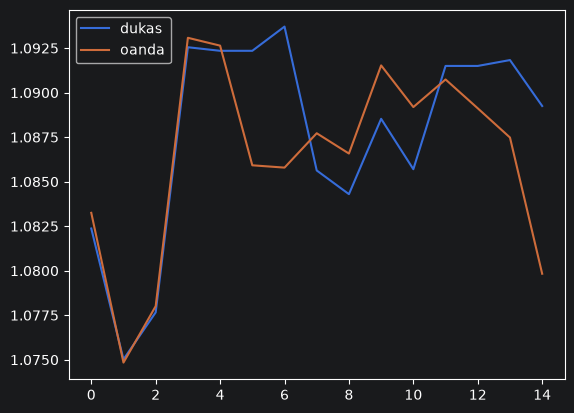

In [86]:
plt.plot(dukas[2:17]['close'], label='dukas')
plt.plot(oanda[0:15]['close'], label='oanda')
plt.legend()

In [87]:
for ccy in ['eur','gbp','aud','nzd','cad','chf','jpy']:
    df = read_oanda_hourly_data(ccy)
    print(f"shape of {ccy} is {df.shape}")

shape of eur is (131368, 5)
shape of gbp is (131221, 5)
shape of aud is (131266, 5)
shape of nzd is (131135, 5)
shape of cad is (131123, 5)
shape of chf is (131225, 5)
shape of jpy is (131287, 5)


In [88]:
oanda_generated_daily= hourly_to_daily(read_oanda_hourly_data(ccy)).filter((pl.col('timestamp') > INITIAL_CUT) & (pl.col('timestamp') < LATER_CUT))

In [89]:
oanda_generated_daily.shape

(3882, 5)

In [90]:
dukas.shape

(3889, 5)

In [91]:
oanda_generated_daily['timestamp'].min()

datetime.datetime(2016, 1, 3, 0, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

In [92]:
oanda_generated_daily['timestamp'].max()

datetime.datetime(2026, 8, 31, 0, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

In [93]:
dukas['timestamp'].min()

datetime.datetime(2016, 1, 2, 0, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

In [94]:
dukas['timestamp'].max()

datetime.datetime(2026, 8, 31, 0, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

In [95]:
dukas[:10]['timestamp']

timestamp
"datetime[ns, UTC]"
2016-01-02 00:00:00 UTC
2016-01-03 00:00:00 UTC
2016-01-04 00:00:00 UTC
2016-01-05 00:00:00 UTC
2016-01-06 00:00:00 UTC
2016-01-07 00:00:00 UTC
2016-01-08 00:00:00 UTC
2016-01-09 00:00:00 UTC
2016-01-10 00:00:00 UTC


In [97]:
oanda_generated_daily[:10]['timestamp']

timestamp
"datetime[ns, UTC]"
2016-01-03 00:00:00 UTC
2016-01-04 00:00:00 UTC
2016-01-05 00:00:00 UTC
2016-01-06 00:00:00 UTC
2016-01-07 00:00:00 UTC
2016-01-08 00:00:00 UTC
2016-01-09 00:00:00 UTC
2016-01-10 00:00:00 UTC
2016-01-11 00:00:00 UTC


In [98]:
dukas['timestamp'].dt.weekday().value_counts()

timestamp,count
i8,u32
1,557
7,555
5,556
2,556
6,553
4,556
3,556


In [99]:
oanda_generated_daily['timestamp'].dt.weekday().value_counts()

timestamp,count
i8,u32
3,556
1,557
2,556
6,554
4,556
7,549
5,554


In [105]:
(dukas['close']-dukas['close'].shift(1)/dukas['close'].shift(1)).describe()

statistic,value
str,f64
"""count""",3888.0
"""null_count""",1.0
"""mean""",0.123511
"""std""",0.053116
"""min""",-0.04047
"""25%""",0.08547
"""50%""",0.12234
"""75%""",0.16561
"""max""",0.25105


In [106]:
(oanda_generated_daily['close']-oanda_generated_daily['close'].shift(1)/oanda_generated_daily['close'].shift(1)).describe()

statistic,value
str,f64
"""count""",3881.0
"""null_count""",1.0
"""mean""",-0.991832
"""std""",0.001191
"""min""",-0.993898
"""25%""",-0.993146
"""50%""",-0.991191
"""75%""",-0.990851
"""max""",-0.98999


In [107]:
oanda_generated_daily['close']

close
f64
0.008311
0.00837
0.008396
0.00843
0.008508
…
0.006277
0.006246
0.006246
